# Task 1: Symbolic Unconditioned Synth-Pop Generation

## Goal

This notebook implements **Task 1: symbolic, unconditioned generation**.

We train models that learn a distribution over symbolic synth-pop MIDI patterns and sample new music from that distribution:

```text
p(x): generated synth-pop sketch = melody + drums
```

The final representation is a standardized **two-track MIDI format**:

1. `Synth Lead` melody track
2. `Drums` track

This choice uses the cleaned melody/drum tracks supplied by our teammate, but recombines them into one consistent symbolic representation for unconditioned generation.


## Why Not Train on Raw Full MIDI Directly?

Raw multi-track MIDI would be the best source to use as train dataset because it contains a full arrangement. However, we found out that the tracks are indeed inconsistent. Different songs have different numbers of tracks, instrument names are noisy, and drum metadata can be lost during decoding.

To make the task stable and readable for peer grading, we standardize every example into the same structure:

**one monophonic melody line + one drum groove**

This is still unconditioned generation because the model receives no prompt at generation time. It simply learns `p(melody, drums)` from the corpus.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MPLCONFIGDIR"] = "/private/tmp/matplotlib-task1"

from pathlib import Path
from collections import Counter, defaultdict
import json
import math
import random

import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 99
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_repo_root(start=None):
    """Find the project root by walking upward until synthpop_data/processed exists."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "synthpop_data" / "processed").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find synthpop_data/processed. "
        "Run this notebook from the repository root or from task1/."
    )

def rel(path):
    """Display paths relative to the repository for cleaner notebook output."""
    path = Path(path).resolve()
    try:
        return path.relative_to(REPO)
    except ValueError:
        return path

REPO = find_repo_root()
DATA_DIR = REPO / "synthpop_data" / "processed"
MELODY_DIR = DATA_DIR / "melodies_all"
DRUM_DIR = DATA_DIR / "drums_all"
TOKEN_DATASET_PATH = DATA_DIR / "task1_combined_grid_dataset.npz"
OUTPUT_DIR = REPO / "task1" / "outputs_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HAS_MIDI_DATA = (
    MELODY_DIR.exists()
    and DRUM_DIR.exists()
    and any(MELODY_DIR.glob("*.mid"))
    and any(DRUM_DIR.glob("*.mid"))
)

print("Repo root detected")
print("Data dir:", rel(DATA_DIR))
print("Melody MIDI dir:", rel(MELODY_DIR), "exists=" + str(MELODY_DIR.exists()))
print("Drum MIDI dir:", rel(DRUM_DIR), "exists=" + str(DRUM_DIR.exists()))
print("Precomputed token dataset:", rel(TOKEN_DATASET_PATH), "exists=" + str(TOKEN_DATASET_PATH.exists()))


Repo root detected
Data dir: synthpop_data/processed
Melody MIDI dir: synthpop_data/processed/melodies_all exists=True
Drum MIDI dir: synthpop_data/processed/drums_all exists=True
Precomputed token dataset: synthpop_data/processed/task1_combined_grid_dataset.npz exists=True


## 1. Dataset Overview

The cleaned synth-pop data contains separate melody and drum MIDI tracks. When the MIDI folders are available, we match files by filename so each training example comes from the same song.

For a lighter GitHub submission, this notebook can also load the precomputed token dataset `synthpop_data/processed/task1_combined_grid_dataset.npz`. That file contains the symbolic event sequences extracted from the processed MIDI files, so the model can still be trained without committing hundreds of `.mid` files.


In [2]:
melody_df = pd.read_csv(DATA_DIR / "melody_dataset.csv")
drum_df = pd.read_csv(DATA_DIR / "drum_dataset.csv")
bpm_df = pd.read_csv(DATA_DIR / "bpm_data.csv")

if MELODY_DIR.exists():
    melody_files = {p.name for p in MELODY_DIR.glob("*.mid")}
else:
    melody_files = {Path(p).name for p in melody_df["melody_path"]}

if DRUM_DIR.exists():
    drum_files = {p.name for p in DRUM_DIR.glob("*.mid")}
else:
    drum_files = {Path(p).name for p in drum_df["drum_path"]}

matched_files = sorted(melody_files & drum_files)

summary = pd.DataFrame({
    "quantity": [
        "melody MIDI files listed",
        "drum MIDI files listed",
        "matched melody+drum files",
        "melody-only files",
        "drum-only files",
        "processed MIDI folders available",
        "precomputed token dataset available",
    ],
    "count": [
        len(melody_files),
        len(drum_files),
        len(matched_files),
        len(melody_files - drum_files),
        len(drum_files - melody_files),
        bool(HAS_MIDI_DATA),
        TOKEN_DATASET_PATH.exists(),
    ],
})
display(summary)

display(melody_df[["instrument_name", "n_notes", "avg_pitch", "bpm"]].describe(include="all"))
display(drum_df[["n_notes", "n_unique_drums", "bpm", "duration"]].describe())


,quantity,count
0,melody MIDI files listed,335
1,drum MIDI files listed,340
2,matched melody+drum files,335
3,melody-only files,0
4,drum-only files,5
5,processed MIDI folders available,True
6,precomputed token dataset available,True


,instrument_name,n_notes,avg_pitch,bpm
count,335,335.000000,335.000000,335.000000
unique,59,NaN,NaN,NaN
top,Lead 1 (square),NaN,NaN,NaN
freq,32,NaN,NaN,NaN
mean,NaN,316.346269,67.298761,116.429386
std,NaN,181.842531,6.183256,16.241638
min,NaN,75.000000,52.298578,70.000233
25%,NaN,191.000000,62.367836,107.001462
50%,NaN,285.000000,67.396970,120.000000
75%,NaN,384.000000,72.296126,126.000126


,n_notes,n_unique_drums,bpm,duration
count,340.000000,340.000000,340.000000,340.000000
mean,2542.991176,9.858824,116.608371,251.816368
std,1407.880579,4.387978,16.199813,55.565585
min,202.000000,1.000000,70.000233,86.086968
25%,1529.000000,7.000000,107.375376,218.291892
50%,2283.000000,9.000000,120.000000,240.557539
75%,3218.250000,12.000000,126.990040,279.014277
max,7443.000000,27.000000,159.000207,456.541536


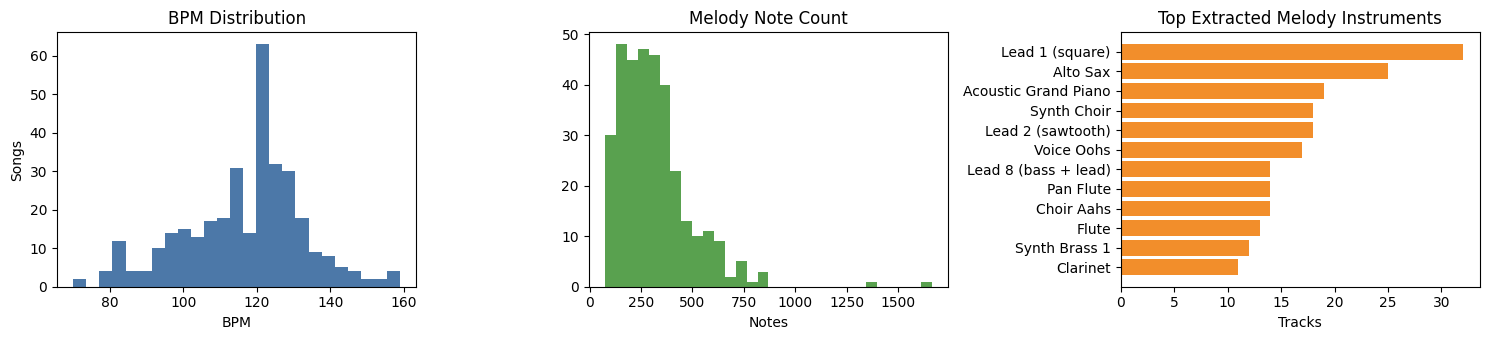

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(melody_df["bpm"], bins=25, color="#4C78A8")
axes[0].set_title("BPM Distribution")
axes[0].set_xlabel("BPM")
axes[0].set_ylabel("Songs")

axes[1].hist(melody_df["n_notes"], bins=30, color="#59A14F")
axes[1].set_title("Melody Note Count")
axes[1].set_xlabel("Notes")

axes[2].barh(
    melody_df["instrument_name"].value_counts().head(12).index[::-1],
    melody_df["instrument_name"].value_counts().head(12).values[::-1],
    color="#F28E2B",
)
axes[2].set_title("Top Extracted Melody Instruments")
axes[2].set_xlabel("Tracks")

plt.tight_layout()
plt.show()


## 2. Symbolic Grid Representation

We quantize every song into 4-bar segments with a 16-step grid per bar.

```text
4 bars x 16 sixteenth-note steps = 64 steps per segment
```

Each time step is converted into one event token:

```text
event = (melody state, drum mask)
```

The melody state distinguishes three cases:

```text
REST = silence
HOLD = previous note continues
PITCH = a new melody note starts
```

The drum mask uses three drum classes:

```text
kick, snare, hi-hat
```

This representation is compact, always decodable, and avoids treating sustained melody notes as repeated rests.


In [4]:
STEPS_PER_BAR = 16
BARS_PER_SEGMENT = 4
SEGMENT_STEPS = STEPS_PER_BAR * BARS_PER_SEGMENT

REST = 0
HOLD = 1
PITCH_OFFSET = 2
MELODY_VOCAB = 130  # 0=rest, 1=hold, 2..129 = MIDI pitch + 2
DRUM_MASKS = 8      # 3 binary drum classes -> 0..7
EVENT_VOCAB = MELODY_VOCAB * DRUM_MASKS
BOS = EVENT_VOCAB
MODEL_VOCAB = EVENT_VOCAB + 1

DRUM_TO_BIT = {
    35: 1, 36: 1,        # kick
    38: 2, 40: 2,        # snare
    42: 4, 44: 4, 46: 4  # hi-hat
}

DRUM_PITCH_FROM_BIT = {
    1: 36,  # kick
    2: 38,  # snare
    4: 42,  # hi-hat
}

def first_bpm(midi_path, fallback=120.0):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    _, tempi = pm.get_tempo_changes()
    return float(tempi[0]) if len(tempi) else float(fallback)

def step_seconds(bpm):
    return (60.0 / float(bpm)) / 4.0

def pitch_token(pitch):
    return int(pitch) + PITCH_OFFSET

def token_pitch(token):
    return int(token) - PITCH_OFFSET

def melody_grid_from_notes(notes, start_time, step_sec, n_steps=SEGMENT_STEPS):
    grid = np.full(n_steps, REST, dtype=np.int64)
    for note in notes:
        raw_start = int(round((note.start - start_time) / step_sec))
        raw_end = int(round((note.end - start_time) / step_sec))
        if raw_end <= 0 or raw_start >= n_steps:
            continue

        start_step = max(raw_start, 0)
        end_step = min(max(raw_end, start_step + 1), n_steps)
        token = pitch_token(note.pitch)

        # A segment may start in the middle of a sustained note. In that case,
        # the first visible step becomes a pitch token so following HOLD tokens
        # still have a concrete pitch to continue.
        if grid[start_step] < token:
            grid[start_step] = token

        for step in range(start_step + 1, end_step):
            if grid[step] == REST:
                grid[step] = HOLD
    return grid

def drum_grid_from_notes(notes, start_time, step_sec, n_steps=SEGMENT_STEPS):
    grid = np.zeros(n_steps, dtype=np.int64)
    for note in notes:
        bit = DRUM_TO_BIT.get(note.pitch)
        if bit is None:
            continue
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < n_steps:
            grid[step] |= bit
    return grid

def encode_events(melody_grid, drum_grid):
    return melody_grid.astype(np.int64) * DRUM_MASKS + drum_grid.astype(np.int64)

def decode_event(event_id):
    melody_token = int(event_id) // DRUM_MASKS
    drum_mask = int(event_id) % DRUM_MASKS
    return melody_token, drum_mask

def extract_segments(melody_path, drum_path, min_melody_notes=8, min_drum_steps=8):
    bpm = first_bpm(melody_path)
    step_sec = step_seconds(bpm)
    segment_sec = step_sec * SEGMENT_STEPS

    melody_pm = pretty_midi.PrettyMIDI(str(melody_path))
    drum_pm = pretty_midi.PrettyMIDI(str(drum_path))

    melody_notes = [note for inst in melody_pm.instruments for note in inst.notes]
    drum_notes = [note for inst in drum_pm.instruments for note in inst.notes]
    end_time = max(melody_pm.get_end_time(), drum_pm.get_end_time())

    segments = []
    start = 0.0
    while start + segment_sec <= end_time:
        melody_grid = melody_grid_from_notes(melody_notes, start, step_sec)
        drum_grid = drum_grid_from_notes(drum_notes, start, step_sec)

        melody_attacks = np.count_nonzero(melody_grid >= PITCH_OFFSET)
        drum_steps = np.count_nonzero(drum_grid)
        if melody_attacks >= min_melody_notes and drum_steps >= min_drum_steps:
            segments.append({
                "events": encode_events(melody_grid, drum_grid),
                "melody": melody_grid,
                "drums": drum_grid,
                "bpm": bpm,
                "start_time": start,
            })
        start += segment_sec
    return segments


In [5]:
dataset_path = TOKEN_DATASET_PATH

if HAS_MIDI_DATA:
    all_segments = []
    skipped = []

    for fname in matched_files:
        melody_path = MELODY_DIR / fname
        drum_path = DRUM_DIR / fname
        try:
            segments = extract_segments(melody_path, drum_path)
            for seg in segments:
                seg["file"] = fname
                all_segments.append(seg)
        except Exception as exc:
            skipped.append((fname, repr(exc)))

    events = np.stack([seg["events"] for seg in all_segments])
    melodies = np.stack([seg["melody"] for seg in all_segments])
    drums = np.stack([seg["drums"] for seg in all_segments])
    bpms = np.array([seg["bpm"] for seg in all_segments])
    files = np.array([seg["file"] for seg in all_segments])

    np.savez_compressed(dataset_path, events=events, melodies=melodies, drums=drums, bpms=bpms, files=files)
    print("Built token dataset from processed MIDI files.")
    print("Matched songs:", len(matched_files))
    print("Skipped files:", len(skipped))
else:
    if not dataset_path.exists():
        raise FileNotFoundError(
            f"No processed MIDI folders were found and {dataset_path} does not exist. "
            "Commit the precomputed token dataset or provide melodies_all/ and drums_all/."
        )
    loaded = np.load(dataset_path, allow_pickle=True)
    events = loaded["events"]
    melodies = loaded["melodies"]
    drums = loaded["drums"]
    bpms = loaded["bpms"]
    files = loaded["files"]
    print("Loaded precomputed token dataset:", rel(dataset_path))

print("Usable 4-bar segments:", len(events))
print("Event tensor shape:", events.shape)
print("Event vocabulary size:", EVENT_VOCAB)
print("Dataset path:", rel(dataset_path))


Built token dataset from processed MIDI files.
Matched songs: 335
Skipped files: 0
Usable 4-bar segments: 5000
Event tensor shape: (5000, 64)
Event vocabulary size: 1040
Dataset path: synthpop_data/processed/task1_combined_grid_dataset.npz


,metric,value
0,usable 4-bar segments,5000.000000
1,unique event tokens observed,375.000000
2,melody attack-step density,0.251341
3,melody hold-step density,0.400612
4,melody active-step density,0.651953
5,drum active-step density,0.551238
6,median BPM,120.000000


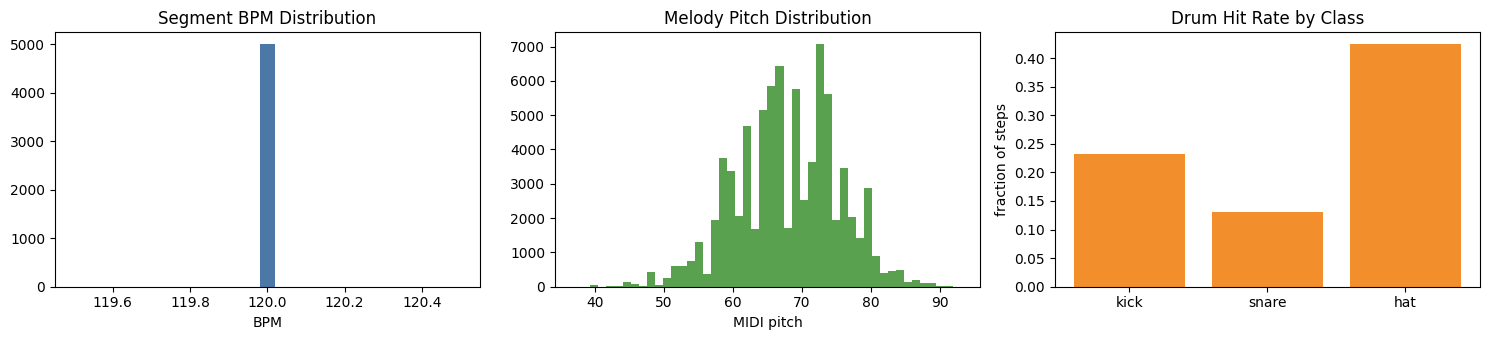

In [6]:
event_counts = Counter(events.flatten().tolist())
melody_attack_density = (melodies >= PITCH_OFFSET).mean()
melody_hold_density = (melodies == HOLD).mean()
melody_active_density = (melodies != REST).mean()
drum_active = (drums > 0).mean()
unique_events = len(event_counts)

stats = pd.DataFrame({
    "metric": [
        "usable 4-bar segments",
        "unique event tokens observed",
        "melody attack-step density",
        "melody hold-step density",
        "melody active-step density",
        "drum active-step density",
        "median BPM",
    ],
    "value": [
        len(events),
        unique_events,
        melody_attack_density,
        melody_hold_density,
        melody_active_density,
        drum_active,
        float(np.median(bpms)),
    ],
})
display(stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(bpms, bins=25, color="#4C78A8")
axes[0].set_title("Segment BPM Distribution")
axes[0].set_xlabel("BPM")

melody_pitches = melodies[melodies >= PITCH_OFFSET] - PITCH_OFFSET
axes[1].hist(melody_pitches, bins=48, color="#59A14F")
axes[1].set_title("Melody Pitch Distribution")
axes[1].set_xlabel("MIDI pitch")

drum_rates = np.array([
    ((drums & 1) > 0).mean(),
    ((drums & 2) > 0).mean(),
    ((drums & 4) > 0).mean(),
])
axes[2].bar(["kick", "snare", "hat"], drum_rates, color="#F28E2B")
axes[2].set_title("Drum Hit Rate by Class")
axes[2].set_ylabel("fraction of steps")

plt.tight_layout()
plt.show()


## 3. Train / Validation Split

We split 4-bar segments into training and validation sets. The validation set is not used for training; it measures how well the model predicts unseen symbolic music segments.


In [7]:
rng = np.random.default_rng(SEED)
indices = np.arange(len(events))
rng.shuffle(indices)

n_val = max(1, int(0.1 * len(indices)))
val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_events = events[train_idx]
val_events = events[val_idx]

print("train segments:", len(train_events))
print("validation segments:", len(val_events))


train segments: 4500
validation segments: 500


## 4. Markov Baseline

The Markov baseline is a simple count model:

```text
p(next_event | previous 4 events)
```

It is fast and interpretable, but it only remembers short exact contexts.


In [8]:
class EventMarkov:
    def __init__(self, order=5, bos_id=BOS):
        self.order = order
        self.context = order - 1
        self.bos_id = bos_id
        self.counts = defaultdict(Counter)
        self.unigrams = Counter()

    def fit(self, sequences):
        for seq in sequences:
            tokens = [self.bos_id] * self.context + list(map(int, seq))
            self.unigrams.update(tokens)
            for i in range(self.context, len(tokens)):
                ctx = tuple(tokens[i-self.context:i])
                self.counts[ctx][tokens[i]] += 1
        return self

    def _counter(self, ctx):
        for start in range(len(ctx) + 1):
            suffix = tuple(ctx[start:])
            if suffix in self.counts:
                return self.counts[suffix]
        return self.unigrams

    def perplexity(self, sequences):
        total_logp = 0.0
        total = 0
        vocab = EVENT_VOCAB
        for seq in sequences:
            tokens = [self.bos_id] * self.context + list(map(int, seq))
            for i in range(self.context, len(tokens)):
                ctx = tuple(tokens[i-self.context:i])
                target = tokens[i]
                counter = self._counter(ctx)
                denom = sum(counter.values()) + vocab
                prob = (counter[target] + 1) / denom
                total_logp += math.log(prob)
                total += 1
        return math.exp(-total_logp / total)

    def generate(self, steps=256, seed=SEED, temperature=0.9, top_k=24):
        rng = random.Random(seed)
        generated = []
        ctx = [self.bos_id] * self.context
        for _ in range(steps):
            counter = self._counter(tuple(ctx[-self.context:]))
            items = [(tok, cnt) for tok, cnt in counter.most_common(top_k) if tok < EVENT_VOCAB]
            if not items:
                items = [(tok, cnt) for tok, cnt in self.unigrams.most_common(top_k) if tok < EVENT_VOCAB]
            toks = [tok for tok, _ in items]
            weights = [cnt ** (1.0 / temperature) for _, cnt in items]
            nxt = rng.choices(toks, weights=weights, k=1)[0]
            generated.append(nxt)
            ctx.append(nxt)
        return np.array(generated, dtype=np.int64)

markov = EventMarkov(order=5).fit(train_events)
markov_ppl = markov.perplexity(val_events)
print(f"Markov validation perplexity: {markov_ppl:.2f}")


Markov validation perplexity: 98.55


## 5. LSTM Event Language Model

The LSTM is the main model. It learns an embedding for each symbolic event and predicts the next event at every time step.

```text
event token -> embedding -> LSTM -> next-event logits
```


In [9]:
class EventDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = torch.LongTensor(sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        x = torch.empty_like(seq)
        x[0] = BOS
        x[1:] = seq[:-1]
        y = seq
        return x, y

class EventLSTM(nn.Module):
    def __init__(self, vocab_size=MODEL_VOCAB, emb_dim=96, hidden_dim=192, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_dim, EVENT_VOCAB)

    def forward(self, x):
        emb = self.embedding(x)
        h, _ = self.lstm(emb)
        return self.head(h)

def evaluate_lstm(model, loader, criterion, device):
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits.reshape(-1, EVENT_VOCAB), y.reshape(-1))
            losses.append(loss.item())
    return float(np.mean(losses))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_loader = DataLoader(EventDataset(train_events), batch_size=64, shuffle=True)
val_loader = DataLoader(EventDataset(val_events), batch_size=64, shuffle=False)

model = EventLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = []
EPOCHS = 25

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits.reshape(-1, EVENT_VOCAB), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss = evaluate_lstm(model, val_loader, criterion, device)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

lstm_val_loss = history[-1]["val_loss"]
lstm_ppl = math.exp(lstm_val_loss)
print(f"LSTM validation perplexity: {lstm_ppl:.2f}")

torch.save(
    {
        "model_state_dict": model.cpu().state_dict(),
        "history": history,
        "event_vocab": EVENT_VOCAB,
        "bos": BOS,
    },
    OUTPUT_DIR / "task1_event_lstm.pt",
)
model.to(device)


device: cpu


epoch 01 | train_loss=3.8501 | val_loss=3.1927


epoch 05 | train_loss=2.6466 | val_loss=2.6224


epoch 10 | train_loss=2.3941 | val_loss=2.3726


epoch 15 | train_loss=2.0507 | val_loss=2.0695


epoch 20 | train_loss=1.7917 | val_loss=1.8556


epoch 25 | train_loss=1.5867 | val_loss=1.6998
LSTM validation perplexity: 5.47


EventLSTM(
  (embedding): Embedding(1041, 96)
  (lstm): LSTM(96, 192, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=192, out_features=1040, bias=True)
)

,epoch,train_loss,val_loss
20,21,1.747019,1.822349
21,22,1.702692,1.791571
22,23,1.660013,1.755637
23,24,1.626328,1.731890
24,25,1.586699,1.699757


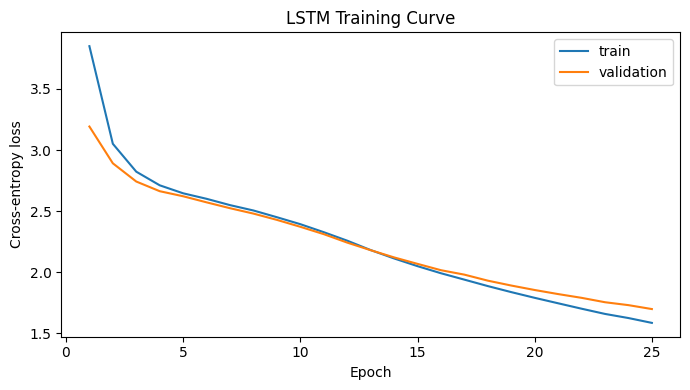

,model,validation_perplexity
0,Markov order-5 baseline,98.547660
1,LSTM event model,5.472616


In [ ]:
hist_df = pd.DataFrame(history)
display(hist_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

metrics = pd.DataFrame({
    "model": ["Markov order-5 `baseline", "LSTM event model"],
    "validation_perplexity": [markov_ppl, lstm_ppl],
})
display(metrics)


## 6. MIDI Decoding and Generation

The model generates event tokens. We decode each token back into:

- melody rest/hold/pitch state
- kick/snare/hi-hat drum mask

`HOLD` tokens extend the most recent pitch, so sustained notes can be reconstructed instead of becoming silent gaps.

The output MIDI is always written as two tracks:

```text
Synth Lead melody
Drums
```


In [11]:
def events_to_grids(event_sequence):
    melody = np.zeros(len(event_sequence), dtype=np.int64)
    drums = np.zeros(len(event_sequence), dtype=np.int64)
    for i, event_id in enumerate(event_sequence):
        melody[i], drums[i] = decode_event(int(event_id))
    return melody, drums

def write_midi_from_events(event_sequence, out_path, bpm=120.0):
    melody_grid, drum_grid = events_to_grids(event_sequence)
    step_sec = step_seconds(bpm)

    pm = pretty_midi.PrettyMIDI(initial_tempo=float(bpm))
    melody_inst = pretty_midi.Instrument(program=80, is_drum=False, name="Generated Synth Lead")
    drum_inst = pretty_midi.Instrument(program=0, is_drum=True, name="Generated Drums")

    # Melody: a pitch token starts a note; following HOLD tokens extend it.
    i = 0
    while i < len(melody_grid):
        token = int(melody_grid[i])
        if token < PITCH_OFFSET:
            i += 1
            continue
        pitch = token_pitch(token)
        j = i + 1
        while j < len(melody_grid) and int(melody_grid[j]) == HOLD:
            j += 1
        start = i * step_sec
        end = max(start + 0.8 * step_sec, j * step_sec)
        melody_inst.notes.append(pretty_midi.Note(velocity=92, pitch=pitch, start=start, end=end))
        i = j

    # Drums: one short hit per active drum class at each step.
    for step, mask in enumerate(drum_grid):
        start = step * step_sec
        end = start + 0.45 * step_sec
        for bit, pitch in DRUM_PITCH_FROM_BIT.items():
            if int(mask) & bit:
                drum_inst.notes.append(pretty_midi.Note(velocity=105, pitch=pitch, start=start, end=end))

    pm.instruments.append(melody_inst)
    pm.instruments.append(drum_inst)
    pm.write(str(out_path))
    return out_path

@torch.no_grad()
def sample_lstm(model, steps=256, seed=SEED, temperature=0.9, top_k=32, device=device):
    torch.manual_seed(seed)
    model.eval()
    generated = []
    x = torch.LongTensor([[BOS]]).to(device)
    hidden = None

    for _ in range(steps):
        emb = model.embedding(x[:, -1:])
        out, hidden = model.lstm(emb, hidden)
        logits = model.head(out[:, -1, :]).squeeze(0).float() / temperature
        if top_k is not None:
            values, idx = torch.topk(logits, k=min(top_k, logits.numel()))
            filtered = torch.full_like(logits, -float("inf"))
            filtered[idx] = values
            logits = filtered
        probs = torch.softmax(logits, dim=-1)
        nxt = int(torch.multinomial(probs, 1).item())
        generated.append(nxt)
        x = torch.LongTensor([[nxt]]).to(device)
    return np.array(generated, dtype=np.int64)

def sample_stats(event_sequence):
    melody_grid, drum_grid = events_to_grids(event_sequence)
    return {
        "melody_attacks": int((melody_grid >= PITCH_OFFSET).sum()),
        "melody_hold_steps": int((melody_grid == HOLD).sum()),
        "melody_active_steps": int((melody_grid != REST).sum()),
        "drum_active_steps": int(np.count_nonzero(drum_grid)),
        "kick_hits": int(((drum_grid & 1) > 0).sum()),
        "snare_hits": int(((drum_grid & 2) > 0).sum()),
        "hat_hits": int(((drum_grid & 4) > 0).sum()),
    }


In [12]:
GEN_BARS = 16
GEN_STEPS = GEN_BARS * STEPS_PER_BAR
GEN_BPM = float(np.median(bpms))
CANDIDATE_SEEDS = range(1, 101)

candidate_rows = []
candidate_events = {}
for seed in CANDIDATE_SEEDS:
    seq = sample_lstm(model, steps=GEN_STEPS, seed=seed, temperature=0.9, top_k=32, device=device)
    stats = sample_stats(seq)
    stats["seed"] = seed
    candidate_rows.append(stats)
    candidate_events[seed] = seq

candidates = pd.DataFrame(candidate_rows)

# Pick a candidate whose melody/drum densities resemble the training corpus.
target_melody_attacks = int(GEN_STEPS * (melodies >= PITCH_OFFSET).mean())
target_melody_active = int(GEN_STEPS * (melodies != REST).mean())
target_drum_active = int(GEN_STEPS * (drums > 0).mean())
target_hat_hits = int(GEN_STEPS * ((drums & 4) > 0).mean())

candidates["score"] = (
    -abs(candidates["melody_attacks"] - target_melody_attacks)
    -0.35 * abs(candidates["melody_active_steps"] - target_melody_active)
    -0.35 * abs(candidates["drum_active_steps"] - target_drum_active)
    -0.25 * abs(candidates["hat_hits"] - target_hat_hits)
)

selection_summary = candidates.sort_values("score", ascending=False).head(10)
display(selection_summary)

best_seed = int(selection_summary.iloc[0]["seed"])
best_events = candidate_events[best_seed]

final_task1_path = OUTPUT_DIR / "symbolic_unconditioned.mid"
root_submission_path = REPO / "symbolic_unconditioned.mid"
write_midi_from_events(best_events, final_task1_path, bpm=GEN_BPM)
write_midi_from_events(best_events, root_submission_path, bpm=GEN_BPM)

markov_events = markov.generate(steps=GEN_STEPS, seed=42, temperature=0.9, top_k=32)
markov_path = OUTPUT_DIR / "markov_baseline_symbolic_unconditioned.mid"
write_midi_from_events(markov_events, markov_path, bpm=GEN_BPM)

print("Selected LSTM seed:", best_seed)
print("Generation bars:", GEN_BARS)
print("Target melody active steps:", target_melody_active)
print("Final Task 1 MIDI:", rel(final_task1_path))
print("Root submission copy:", rel(root_submission_path))
print("Markov baseline MIDI:", rel(markov_path))


,melody_attacks,melody_hold_steps,melody_active_steps,drum_active_steps,kick_hits,snare_hits,hat_hits,seed,score
39,47,117,164,133,59,37,128,40,-25.50
43,58,65,123,127,33,13,121,44,-29.20
59,48,128,176,109,35,25,102,60,-32.20
81,49,99,148,113,65,23,97,82,-33.85
38,48,104,152,104,44,12,104,39,-34.85
54,43,108,151,123,49,32,120,55,-35.55
30,46,92,138,134,55,40,130,31,-35.75
73,50,108,158,97,15,8,88,74,-37.20
13,40,104,144,127,41,25,102,14,-38.10
45,55,49,104,131,57,31,129,46,-39.45


Selected LSTM seed: 40
Generation bars: 16
Target melody active steps: 166
Final Task 1 MIDI: task1/outputs_final/symbolic_unconditioned.mid
Root submission copy: symbolic_unconditioned.mid
Markov baseline MIDI: task1/outputs_final/markov_baseline_symbolic_unconditioned.mid


In [13]:
def midi_note_count(path):
    pm = pretty_midi.PrettyMIDI(str(path))
    return sum(len(inst.notes) for inst in pm.instruments), [(inst.name, inst.is_drum, inst.program, len(inst.notes)) for inst in pm.instruments]

for path in [final_task1_path, markov_path]:
    n_notes, track_info = midi_note_count(path)
    print(path.name, "notes:", n_notes)
    for row in track_info:
        print("  ", row)


symbolic_unconditioned.mid notes: 271
   ('Generated Synth Lead', False, np.int64(80), 47)
   ('Generated Drums', True, np.int64(0), 224)
markov_baseline_symbolic_unconditioned.mid notes: 192
   ('Generated Synth Lead', False, np.int64(80), 73)
   ('Generated Drums', True, np.int64(0), 119)


## 7. Evaluation Discussion

The Markov baseline provides a useful floor: it captures local rhythmic and melodic event transitions, but only through exact short contexts. The LSTM is more flexible because it learns distributed event embeddings and a hidden state across the 64-step training segment.

The revised symbolic representation separates melody silence from sustain:

```text
REST = no melody note
HOLD = previous melody note continues
PITCH = new melody note starts
```

This matters because sustained melody notes should not be learned as repeated silence. The evaluation has two parts:

1. **Objective next-token prediction**: validation perplexity for Markov and LSTM.
2. **Musical sanity checks**: generated MIDI contains both synth lead notes and drum hits, uses consistent instrument metadata, and can be opened by a MIDI player.

This project does not claim that validation perplexity fully captures musical quality. Perplexity measures predictive fit to the corpus, while subjective musical quality also depends on phrase structure, repetition, timbre, and listener preference.


## 8. Final Task 1 Output

The selected generated MIDI file is saved as:

```text
symbolic_unconditioned.mid
```

It contains two tracks:

1. Generated Synth Lead
2. Generated Drums

This is the Task 1 music file to submit for the symbolic unconditioned generation component.
